<a href="https://colab.research.google.com/github/AnjanaJolly00/applied-machine-learning/blob/main/pytorch_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import torch
import pandas as pd
import numpy as np
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [26]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train = False, download=True, transform=transforms.ToTensor())

download=True → downloads MNIST automatically

train=True → training data (60,000 images)

train=False → test data (10,000 images)

transforms.ToTensor() → converts images to PyTorch tensors

In [27]:

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

DataLoader does three things:

splits data into batches

shuffles the training data

feeds data to the model efficiently


shuffle=True (for training)
→ mixes the data every epoch so the model learns better

In [33]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


64 images in the batch
1 channel
28x28 pixels

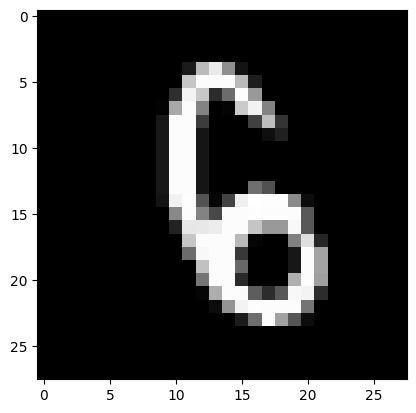

In [34]:
plt.imshow(images[23].squeeze(), cmap='gray')
plt.show()

In [35]:
class MNISTModel(nn.Module):
  def __init__(self):
    super(MNISTModel, self).__init__()
    self.layer1 = nn.Linear(784,128)
    self.layer2 = nn.Linear(128,64)
    self.layer3 = nn.Linear(64,10)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = x.view(-1, 784)
    # flatten the image (28x28 → 784)
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x= self.layer3(x)
    return x



In [36]:
model = MNISTModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [37]:
epochs = 10
for epoch in range(epochs):
  for images, labels in train_loader:

    #flatten images

    output = model(images)
    #forward

    loss = criterion(output, labels)
    #calculate loss

    optimizer.zero_grad()
    #reset

    loss.backward()
    #backprop

    optimizer.step()
    #update weights

  print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

Epoch 1/10, Loss: 0.13591022789478302
Epoch 2/10, Loss: 0.30407437682151794
Epoch 3/10, Loss: 0.07214763015508652
Epoch 4/10, Loss: 0.009134790860116482
Epoch 5/10, Loss: 0.00933845154941082
Epoch 6/10, Loss: 0.0049466718919575214
Epoch 7/10, Loss: 0.0005213123513385653
Epoch 8/10, Loss: 0.032107532024383545
Epoch 9/10, Loss: 0.0772167444229126
Epoch 10/10, Loss: 0.01135742012411356


In [28]:
correct = 0
total = 0
with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    _, predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (predicted ==labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.78%


Predicted: 2, Actual: 2


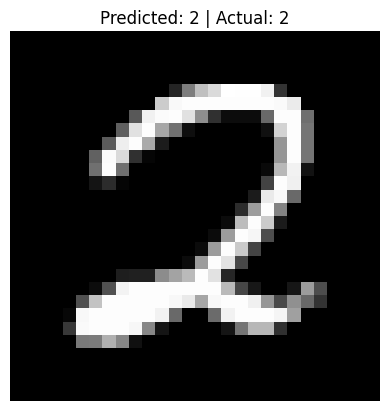

In [43]:
image, labels = next(iter(test_loader))
image = image[35]
labels = labels[35]

image_flat = image.view(-1,784)

with torch.no_grad():
  output = model(image_flat)
  _, predicted = torch.max(output,1)

print(f'Predicted: {predicted.item()}, Actual: {labels.item()}')

plt.imshow(image.squeeze(),cmap='gray')
plt.title(f"Predicted: {predicted.item()} | Actual: {labels.item()}")
plt.axis("off")
plt.show()
